# Detecção de objetos usando mapas de ativação

1. Coletar 10 imagens da internet possuindo um cachorro. O cachorro deve ocupar uma parte pequena da imagem, diferentemente do dataset Oxford Pets no qual o animal ocupa quase a imagem toda
2. Utilizar o código abaixo para obter as ativações da última camada da ResNet18 treinada no ImageNet antes do pooling global
3. Detectar a posição do valor máximo da ativação;
4. Calcular a posição respectiva do valor máximo na **imagem original**;
5. Repetir o procedimento utilizando a ResNet18 refinada no dataset Oxford Pets e para a ResNet50 treinada no ImageNet
6. Avaliar a acurácia de forma qualitativa e discutir os resultados

Note que a imagem original possui um tamanho qualquer. Ela é redimensionada para o tamanho 2\*224x2\*224. O mapa de ativação possui tamanho 14x14. Então é preciso realizar alguns cálculos para relacionar a posição do máximo no mapa de ativação e a respectiva posição na imagem original. 

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import models
import torchvision.transforms.v2 as transf

class Transforms:
    def __init__(self):

        transforms = transf.Compose([
            transf.PILToTensor(),
            transf.Resize(size=(2*224,2*224), antialias=True),
            transf.ToDtype(torch.float32),
            transf.Normalize(mean=(122.7, 114.6, 100.9), std=(59.2, 58.4, 59.0))
        ])

        self.transforms = transforms

    def __call__(self, img):
        return self.transforms(img)
    
class ModelMap(nn.Module):
    """Extrai as ativações antes do global pooling de uma resnet18. É retornada
    uma imagem contendo a média das ativações para todos os filtros. Para o 
    modelo funcionar, a imagem de entrada deve ter tamanho 224x224."""

    def __init__(self):
        super().__init__()

        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.eval()
        model.avgpool = nn.Identity()
        model.fc = nn.Identity()

        self.model = model

    def forward(self, x):

        x = self.model(x)
        # x = x.reshape(512, 14, 14)
        x = x.reshape(2048, 14, 14)   # Para a resnet50

        return x.mean(dim=0)
      
img = Image.open('man_with_dog.jpg')
transform = Transforms()

model = ModelMap()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/wesleygalvao/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 94.2MB/s]


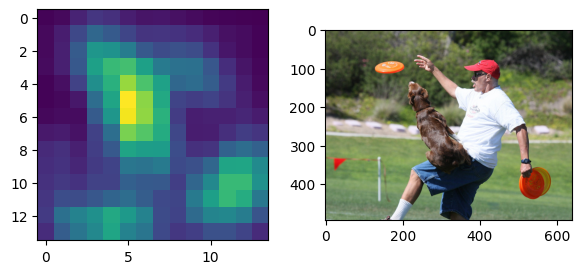

In [6]:
img_t = transform(img)
with torch.no_grad():
    map = model(img_t.unsqueeze(0))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,3))
ax1.imshow(map)
ax2.imshow(img)
